# KNN Classification Demo With Evaluation Metrics

Dataset: Iris  
    
    1. KNN CLassification   
    2. Confusion Matrix   
    3. Accuracy, Precision, Recall, F1 Score  
    4. ROC Curve and AUC  
    5. Choosing the best k using accuracy plot  

In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

In [7]:
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = (data.target == 2).astype(int)

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)


In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred = knn.predict(X_test)
prob = knn.predict_proba(X_test)[:,1]

In [13]:
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print('Accuracy:', acc)
print('Precision:', prec)
print('Recall:', rec)
print('F1 Score:', f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [14]:
cm = confusion_matrix(y_test, pred)
print(cm)

[[32  0]
 [ 0 13]]


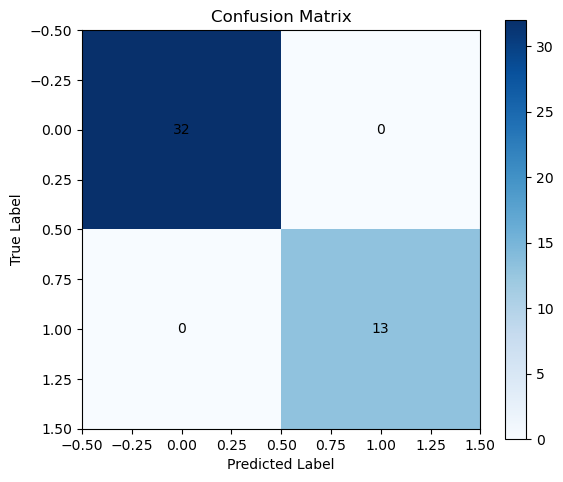

In [20]:
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.colorbar()

#generate number to matrix

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                ha = 'center', va='center',
                color='black')
plt.tight_layout()
plt.show()

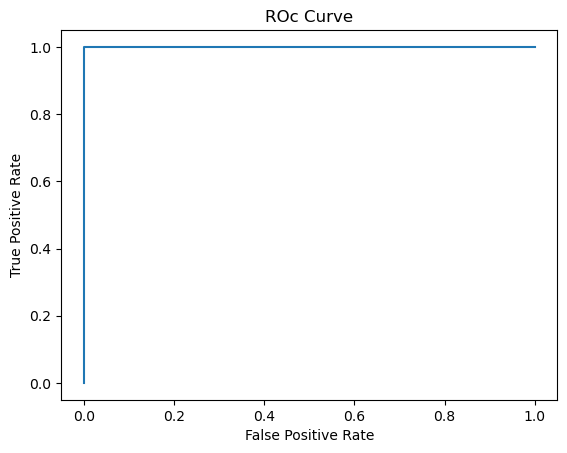

AUC: 1.0


In [23]:
fpr, tpr, thresholds = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title('ROc Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

print('AUC:', roc_auc)

In [25]:
k_values = range(1,21)
acc_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    acc_scores.append(accuracy_score(y_test, p))

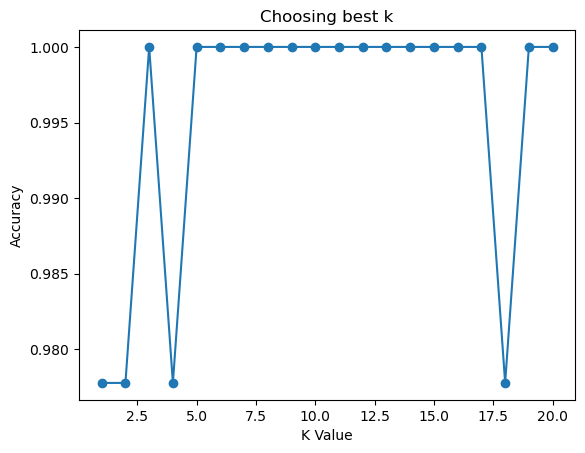

In [26]:
plt.figure()
plt.plot(list(range(1,21)), acc_scores, marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Choosing best k')
plt.show()